# 02 - Auditoria de qualidade das imagens

Este notebook documenta a auditoria tecnica das imagens JPEG antes da modelagem.

A auditoria verifica disponibilidade, formato, dimensoes, legibilidade, duplicatas exatas e estatisticas simples de intensidade. Ela nao valida uso clinico; apenas qualifica os arquivos disponiveis para um estudo exploratorio de visao computacional.


## tl;dr

- A auditoria usa artefatos derivados em `data/interim/`, principalmente `image_quality_audit.csv`.
- As checagens principais sao: arquivos ausentes, imagens ilegiveis, dimensoes, extensoes, canais/formato e duplicatas exatas por hash.
- Estatisticas de intensidade em JPEG nao devem ser interpretadas como HU clinico.
- Se os artefatos locais nao existirem, execute `python scripts/audit_images.py` depois de criar indice e split.


## Contexto & Metodos

Script principal desta etapa:

```bash
python scripts/audit_images.py
```

Entradas esperadas:

- `data/interim/split_slices.csv`, preferencialmente.
- `data/interim/dataset_index.csv`, se o split ainda nao existir.

Saidas esperadas:

- `data/interim/image_quality_audit.csv`.
- `data/interim/duplicate_hashes.csv`.
- `data/interim/image_quality_summary.json`.

### Key Assumptions

- Cada linha auditada representa um arquivo de imagem JPEG.
- `class_name`, `label` e `inferred_group_id` vem dos indices derivados.
- A auditoria e descritiva; nao ha modelagem nem inferencia causal.
- Valores de pixel sao intensidades da imagem JPEG exportada, nao unidades Hounsfield.


## Setup

Carregamos bibliotecas, caminhos e pequenas funcoes auxiliares.


In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import display, Markdown, Image
from PIL import Image as PILImage

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
REPORT_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES = PROJECT_ROOT / "reports" / "figures"

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 30)


def read_csv_if_exists(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        print(f"Arquivo nao encontrado: {path}")
        return None
    return pd.read_csv(path)


def read_json_if_exists(path: Path) -> dict | None:
    if not path.exists():
        print(f"Arquivo nao encontrado: {path}")
        return None
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


## Data

Carregamos os arquivos de auditoria, quando disponiveis.


In [2]:
audit_df = read_csv_if_exists(DATA_INTERIM / "image_quality_audit.csv")
duplicates_df = read_csv_if_exists(DATA_INTERIM / "duplicate_hashes.csv")
audit_summary = read_json_if_exists(DATA_INTERIM / "image_quality_summary.json")

if audit_df is None:
    print("Para gerar a auditoria localmente, execute:")
    print("python scripts/build_dataset_index.py")
    print("python scripts/build_splits.py")
    print("python scripts/audit_images.py")
else:
    print("Linhas auditadas:", len(audit_df))
    display(audit_df.head())


Linhas auditadas: 3557


,class_name,label,filename,inferred_group_id,slice_id,extension,file_size_bytes,width,height,is_readable,file_path,split,file_exists,md5,width_audit,height_audit,mean_intensity,std_intensity,min_intensity,max_intensity,is_readable_audit,audit_error
0,Healthy,0,106-img-00060-00214.jpg,106-img-00060,214,.jpg,32835,256,256,True,C:\GitHub\Liver_CT_Image_Dataset\Healthy\106-i...,test,True,ababfef2114df2ebd6180eee2227addf,256,256,25.131180,53.316214,0,255,True,NaN
1,Healthy,0,106-img-00060-00215.jpg,106-img-00060,215,.jpg,33514,256,256,True,C:\GitHub\Liver_CT_Image_Dataset\Healthy\106-i...,test,True,6a73f922a6ce380cd0b3b6b8055b31fb,256,256,25.941360,54.098409,0,255,True,NaN
2,Healthy,0,106-img-00060-00216.jpg,106-img-00060,216,.jpg,33583,256,256,True,C:\GitHub\Liver_CT_Image_Dataset\Healthy\106-i...,test,True,cd6529cf2f4b707afb889ad146305c9e,256,256,26.481476,54.530986,0,255,True,NaN
3,Healthy,0,106-img-00060-00217.jpg,106-img-00060,217,.jpg,33943,256,256,True,C:\GitHub\Liver_CT_Image_Dataset\Healthy\106-i...,test,True,f11d6e6afda912041f95e2c5619c9be8,256,256,27.129120,54.898553,0,255,True,NaN
4,Healthy,0,106-img-00060-00218.jpg,106-img-00060,218,.jpg,34246,256,256,True,C:\GitHub\Liver_CT_Image_Dataset\Healthy\106-i...,test,True,f5fcbecda66ef7a5a41c8c52794386a3,256,256,27.678421,54.816362,0,255,True,NaN


## Quantidade, formatos e legibilidade

A primeira validacao confirma volume de arquivos, extensoes e se as imagens puderam ser abertas.


In [3]:
if audit_df is not None:
    overview = pd.DataFrame({
        "metric": ["total_images", "missing_files", "unreadable_images", "unique_groups", "unique_classes"],
        "value": [
            len(audit_df),
            int((~audit_df["file_exists"].astype(bool)).sum()) if "file_exists" in audit_df else None,
            int((~audit_df["is_readable_audit"].astype(bool)).sum()) if "is_readable_audit" in audit_df else None,
            audit_df["inferred_group_id"].nunique() if "inferred_group_id" in audit_df else None,
            audit_df["class_name"].nunique() if "class_name" in audit_df else None,
        ],
    })
    display(overview)

    if "extension" in audit_df:
        display(audit_df["extension"].value_counts(dropna=False).rename_axis("extension").reset_index(name="n_files"))


,metric,value
0,total_images,3557
1,missing_files,0
2,unreadable_images,0
3,unique_groups,225
4,unique_classes,2


,extension,n_files
0,.jpg,3557


## Dimensoes e canais

As dimensoes sao lidas pela auditoria. Para canais/modo de imagem, a celula abaixo abre uma amostra pequena e mostra o modo PIL (`L`, `RGB`, etc.).


In [4]:
if audit_df is not None:
    if {"width_audit", "height_audit"}.issubset(audit_df.columns):
        dimensions = (
            audit_df.groupby(["width_audit", "height_audit"])
            .size()
            .reset_index(name="n_images")
            .sort_values("n_images", ascending=False)
        )
        display(dimensions)

    readable = audit_df.copy()
    if "file_exists" in readable:
        readable = readable[readable["file_exists"].astype(bool)]
    if "is_readable_audit" in readable:
        readable = readable[readable["is_readable_audit"].astype(bool)]

    mode_rows = []
    for row in readable.head(20).to_dict(orient="records"):
        image_path = Path(row["file_path"])
        if image_path.exists():
            with PILImage.open(image_path) as image:
                mode_rows.append({
                    "filename": row.get("filename"),
                    "class_name": row.get("class_name"),
                    "mode": image.mode,
                    "width": image.size[0],
                    "height": image.size[1],
                })
    display(pd.DataFrame(mode_rows))


,width_audit,height_audit,n_images
0,256,256,3557


,filename,class_name,mode,width,height
0,106-img-00060-00214.jpg,Healthy,RGB,256,256
1,106-img-00060-00215.jpg,Healthy,RGB,256,256
2,106-img-00060-00216.jpg,Healthy,RGB,256,256
3,106-img-00060-00217.jpg,Healthy,RGB,256,256
4,106-img-00060-00218.jpg,Healthy,RGB,256,256
5,106-img-00060-00219.jpg,Healthy,RGB,256,256
6,106-img-00060-00220.jpg,Healthy,RGB,256,256
7,106-img-00060-00221.jpg,Healthy,RGB,256,256
8,106-img-00060-00222.jpg,Healthy,RGB,256,256
9,106-img-00060-00223.jpg,Healthy,RGB,256,256


## Duplicatas exatas

Duplicatas exatas sao verificadas por hash MD5. O esperado, conforme documentacao existente, e nao haver grupos de duplicatas exatas.


In [5]:
if duplicates_df is not None:
    print("Linhas em duplicate_hashes.csv:", len(duplicates_df))
    if duplicates_df.empty:
        display(Markdown("**OK:** nenhuma duplicata exata registrada."))
    else:
        display(duplicates_df.head(20))


Linhas em duplicate_hashes.csv: 0


**OK:** nenhuma duplicata exata registrada.

## Resumo por classe e por split

Estas tabelas ajudam a identificar diferencas tecnicas entre classes ou splits. Elas nao devem ser usadas como evidencia clinica isolada.


In [6]:
if audit_df is not None:
    by_class = (
        audit_df.groupby("class_name")
        .agg(
            n_images=("filename", "count"),
            n_groups=("inferred_group_id", "nunique"),
            mean_intensity_avg=("mean_intensity", "mean"),
            std_intensity_avg=("std_intensity", "mean"),
            file_size_avg=("file_size_bytes", "mean"),
        )
        .round(4)
        .reset_index()
    )
    display(by_class)

    if "split" in audit_df.columns:
        by_split_class = (
            audit_df.groupby(["split", "class_name"])
            .agg(
                n_images=("filename", "count"),
                n_groups=("inferred_group_id", "nunique"),
                mean_intensity_avg=("mean_intensity", "mean"),
                std_intensity_avg=("std_intensity", "mean"),
                file_size_avg=("file_size_bytes", "mean"),
            )
            .round(4)
            .reset_index()
            .sort_values(["split", "class_name"])
        )
        display(by_split_class)


,class_name,n_images,n_groups,mean_intensity_avg,std_intensity_avg,file_size_avg
0,Healthy,1611,76,39.4444,61.2759,38595.2092
1,Hepatic_Steatosis,1946,149,40.1071,58.5789,41793.7174


,split,class_name,n_images,n_groups,mean_intensity_avg,std_intensity_avg,file_size_avg
0,test,Healthy,260,12,40.5170,61.9478,40007.5885
1,test,Hepatic_Steatosis,300,23,43.1512,59.7174,42006.1167
2,train,Healthy,1095,53,39.3134,61.1031,38471.4831
3,train,Hepatic_Steatosis,1364,104,39.8037,58.5942,41583.5711
4,val,Healthy,256,11,38.9155,61.3331,37689.9805
5,val,Hepatic_Steatosis,282,22,38.3357,57.2938,42584.2128


## Exemplos de imagens validas

A celula abaixo mostra poucos exemplos por classe, evitando muitos slices do mesmo grupo. As imagens sao exibidas apenas se os caminhos locais estiverem disponiveis.


Healthy 1-img-00004 1-img-00004-00080.jpg


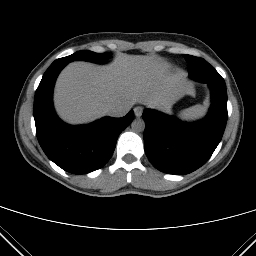

Healthy 100-img-00054 100-img-00054-00001.jpg


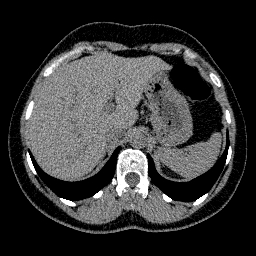

Hepatic_Steatosis 10-img-00011 10-img-00011-00019.jpg


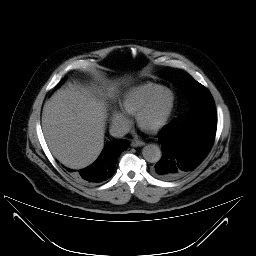

Hepatic_Steatosis 101-img-00055 101-img-00055-00217.jpg


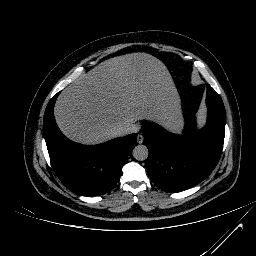

In [7]:
if audit_df is not None:
    readable = audit_df.copy()
    if "file_exists" in readable:
        readable = readable[readable["file_exists"].astype(bool)]
    if "is_readable_audit" in readable:
        readable = readable[readable["is_readable_audit"].astype(bool)]

    sample_rows = (
        readable.sort_values(["class_name", "inferred_group_id", "slice_id", "filename"])
        .groupby(["class_name", "inferred_group_id"], as_index=False)
        .first()
        .groupby("class_name", group_keys=False)
        .head(2)
    )

    for row in sample_rows.to_dict(orient="records"):
        image_path = Path(row["file_path"])
        print(row["class_name"], row["inferred_group_id"], row.get("filename"))
        if image_path.exists():
            display(Image(filename=str(image_path), width=220))


## Results

A auditoria qualifica os arquivos disponiveis, mas nao transforma JPEG em dado clinico quantitativo. Ela ajuda a responder se os arquivos existem, podem ser carregados, possuem dimensoes consistentes, tem duplicatas exatas e se ha diferencas tecnicas simples entre classes ou splits.


## Takeaways

Limitacoes que devem acompanhar qualquer apresentacao:

- imagens em JPEG com compressao e sem metadados DICOM;
- ausencia de NIfTI/volume 3D estruturado;
- ausencia de valores HU confiaveis;
- ausencia de metadados clinicos;
- ausencia de segmentacao hepatica validada.

Portanto, a auditoria permite organizar e qualificar os dados disponiveis, mas nao valida uso clinico nem diagnostico autonomo.
